# 木薯横截面坏死分割识别（UNet）

## 项目背景
    本赛题以“智汇八桂 数启新程”为主题，鼓励探索面向东盟的跨境贸易、数字经济与数字社会的创新发展。广西作为中国面向东盟开放合作的前沿和窗口，是东盟农产品进入中国的重要枢纽。据最新海关贸易数据显示，2026年1-7月，仅越南向中国大陆出口的木薯及其制品就高达196.02万吨，泰国出口达65.71万吨。仅广西一省，今年1-6月的木薯进口量就高达81.99万吨。庞大且高频的跨境贸易，使得木薯成为了极具“东盟特色”的贸易大宗商品。 
    然而，大量涌入的木薯却带来了严峻的品质把控难题。木薯采后极易发生块根坏死（腐烂褐变），病斑形状极其不规则且边缘模糊，严重影响木薯淀粉纯度，直接造成原材料浪费。目前，海关口岸及加工厂主要依赖人工肉眼分拣，不仅效率低下、成本高昂，且极易受主观经验和光线环境影响，漏检误判频发，导致优质原料被低价处理，劣质原料混入生产，造成巨大经济损失。这本质上是对跨境贸易数据（图像数据）缺乏高效利用和智能化挖掘的问题。 为响应赛题“结合创新思维，推动数字经济与数字社会在区域合作中的创新发展”的号召，本项目发挥技术优势，将公共数据与企业需求结合，创新性地引入基于U-Net的语义分割网络模型，构建了一套面向跨境贸易的木薯自动化、非接触式品质分级系统。 
### 掩码标签映射（以实际数据为准）
| 原始灰度值 | 类别 | 可视化颜色 |
|---|---|---|
| 0 | 背景（手掌、泥土等） | 黑色 |
| 75 | 健康薯肉 | 绿色 |
| 38 | 坏死病斑 | 红色 |

> **注意**：经实际数据验证，数据集中灰度值 **75 对应健康薯肉**（大面积区域），**38 对应坏死病斑**（小面积斑点）。

### 数据集： 
本实验所采用的数据集为 Makerere 大学人工智能实验室与乌干达国家作物资源研究所等机构联合发布的“木薯根横切面图像数据集”（Cassava root cross-section images, Version 3, DOI: 10.17632/gvp7vshvnh.3）。该数据集共包含来自5个田间试验的10,052张木薯横切面图像，本项目采用1,036张带有像素级坏死区域标注掩码的图像对，以及251张未标注测试图像。数据获取地址为：https://data.mendeley.com/datasets/gvp7vshvnh/3。

### 坏死严重程度分级（三级）
| 坏死占比 | 等级 | 图上显示（英文） |
|---|---|---|
| <= 5% | 轻度（一级） | Mild (L1) |
| > 5% 且 <= 20% | 中度（二级） | Moderate (L2) |
| > 20% | 重度（三级） | Severe (L3) |

分级参考来源：https://guangxibiaoxie.com/uploads/20220803/6a71d37778cfafff73ddf7ddb29a7aa4.pdf
https://www.fao.org/fao-who-codexalimentarius/sh-proxy/zh/?lnk=1&url=https%253A%252F%252Fworkspace.fao.org%252Fsites%252Fcodex%252FStandards%252FCXS%2B238-2003%252FCXS_238c.pdf


### 坏死占比计算公式
$$\text{坏死占比} = \frac{\text{坏死病斑像素数}}{\text{健康像素数} + \text{坏死像素数}} \times 100\%$$

---


## 一、数据集导入

### 1.1 导入所需库

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import warnings
warnings.filterwarnings('ignore')

# 设置随机种子，保证结果可复现
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("所有库导入成功。")
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 是否可用: {torch.cuda.is_available()}")

所有库导入成功。
PyTorch 版本: 2.1.2+cu121
CUDA 是否可用: True


### 1.2 配置路径与数据读取函数

In [2]:
# ==================== 配置参数 ====================
BASE_DIR = "/root/autodl-tmp/shujuji"
IMAGE_DIR = os.path.join(BASE_DIR, "images")
MASK_DIR = os.path.join(BASE_DIR, "masks")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 4
EPOCHS = 150
LEARNING_RATE = 1e-4
IMG_SIZE = 256
NUM_WORKERS = 2
VAL_SPLIT = 0.2

# 标签映射：原始灰度值 -> 类别索引
# 实际数据: 0=背景, 75=健康薯肉, 38=坏死病斑
LABEL_MAP = {0: 0, 75: 1, 38: 2}
NUM_CLASSES = 3
CLASS_NAMES = ['Background', 'Healthy', 'Necrotic']

# 分级阈值
MILD_THRESHOLD = 5.0
MODERATE_THRESHOLD = 20.0

print(f"使用设备: {DEVICE}")
print(f"图像目录: {IMAGE_DIR}")
print(f"掩码目录: {MASK_DIR}")

# ==================== 数据读取函数 ====================
def get_file_pairs(image_dir, mask_dir):
    img_files = sorted([f for f in os.listdir(image_dir)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    mask_files = sorted([f for f in os.listdir(mask_dir)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    pairs = []
    for img_f in img_files:
        base = os.path.splitext(img_f)[0]
        if base in mask_dict:
            pairs.append((os.path.join(image_dir, img_f),
                          os.path.join(mask_dir, mask_dict[base])))
        else:
            print(f"警告: 未找到 {img_f} 对应的掩码")
    return pairs

def load_image(file_path):
    img = cv2.imread(file_path)
    if img is None:
        raise FileNotFoundError(f"无法读取图像: {file_path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_mask(file_path):
    mask = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise FileNotFoundError(f"无法读取掩码: {file_path}")
    return mask

def remap_mask(mask):
    remapped = np.zeros_like(mask, dtype=np.uint8)
    for orig_val, class_idx in LABEL_MAP.items():
        remapped[mask == orig_val] = class_idx
    return remapped

def classify_grade(ratio):
    """根据坏死占比返回中文等级。"""
    if ratio <= MILD_THRESHOLD:
        return "轻度（一级）"
    elif ratio <= MODERATE_THRESHOLD:
        return "中度（二级）"
    else:
        return "重度（三级）"

def grade_to_english(grade_cn):
    """将中文等级转换为英文，用于图片标注（避免中文乱码）。"""
    mapping = {
        "轻度（一级）": "Mild (L1)",
        "中度（二级）": "Moderate (L2)",
        "重度（三级）": "Severe (L3)",
        "未检测到木薯": "No Cassava"
    }
    return mapping.get(grade_cn, grade_cn)

# ==================== 扫描数据集 ====================
file_pairs = get_file_pairs(IMAGE_DIR, MASK_DIR)
print(f"\n匹配到的图像-掩码对总数: {len(file_pairs)}")
if len(file_pairs) == 0:
    raise RuntimeError("未找到图像-掩码对，请检查数据集路径。")

train_pairs, val_pairs = train_test_split(
    file_pairs, test_size=VAL_SPLIT, random_state=SEED
)
print(f"训练集: {len(train_pairs)} 张")
print(f"验证集: {len(val_pairs)} 张")

使用设备: cuda
图像目录: /root/autodl-tmp/shujuji/images
掩码目录: /root/autodl-tmp/shujuji/masks

匹配到的图像-掩码对总数: 1036
训练集: 828 张
验证集: 208 张


### 1.3 掩码灰度值分布验证

统计掩码中各灰度值的像素数量，确认标签映射正确。健康薯肉应占大面积，坏死病斑占小面积。

In [3]:
print("=" * 60)
print("掩码灰度值分布验证（前5张样本）")
print("=" * 60)

for i in range(min(5, len(file_pairs))):
    _, mask_path = file_pairs[i]
    mask = load_mask(mask_path)
    total = mask.size
    vals, counts = np.unique(mask, return_counts=True)
    print(f"\n样本 {i+1}: {os.path.basename(mask_path)}")
    for v, c in zip(vals, counts):
        pct = c / total * 100
        label = "背景" if v == 0 else ("健康薯肉" if v == 75 else ("坏死病斑" if v == 38 else f"未知({v})"))
        print(f"  灰度值 {v:3d}: {c:>8d} 像素 ({pct:5.1f}%) -> {label}")

print("\n" + "=" * 60)
print("验证结论: 灰度值 75 占比最大（健康薯肉），灰度值 38 占比较小（坏死病斑）")
print("=" * 60)

掩码灰度值分布验证（前5张样本）

样本 1: image-1.png
  灰度值   0:  3616826 像素 ( 73.6%) -> 背景
  灰度值  38:    11070 像素 (  0.2%) -> 坏死病斑
  灰度值  75:  1287304 像素 ( 26.2%) -> 健康薯肉

样本 2: image-10.png
  灰度值   0:  3194216 像素 ( 65.0%) -> 背景
  灰度值  38:    35914 像素 (  0.7%) -> 坏死病斑
  灰度值  75:  1685070 像素 ( 34.3%) -> 健康薯肉

样本 3: image-100.png
  灰度值   0:  4144080 像素 ( 84.3%) -> 背景
  灰度值  38:    60780 像素 (  1.2%) -> 坏死病斑
  灰度值  75:   710340 像素 ( 14.5%) -> 健康薯肉

样本 4: image-1000.png
  灰度值   0:  1883261 像素 ( 38.3%) -> 背景
  灰度值  38:    25415 像素 (  0.5%) -> 坏死病斑
  灰度值  75:  3006524 像素 ( 61.2%) -> 健康薯肉

样本 5: image-1001.png
  灰度值   0:  3530911 像素 ( 71.8%) -> 背景
  灰度值  38:  1233804 像素 ( 25.1%) -> 坏死病斑
  灰度值  75:   150485 像素 (  3.1%) -> 健康薯肉

验证结论: 灰度值 75 占比最大（健康薯肉），灰度值 38 占比较小（坏死病斑）


### 1.4 计算数据集 RGB 均值与标准差

为完成图像归一化预处理，遍历全部样本图像，统计本数据集 RGB 三通道的像素均值与标准差。本项目**不直接采用 ImageNet 预训练数据集的通用统计参数**：木薯切片图像以薯肉、暗褐色病斑为主，整体色调偏暗，色彩分布与 ImageNet 自然场景图像存在显著差异，使用数据集自身统计量进行归一化，可以更好适配图像真实灰度分布，提升分割模型训练收敛效果。

In [4]:
# 计算数据集 RGB 均值和标准差（遍历全部图像）
pixel_sum = np.zeros(3, dtype=np.float64)
pixel_sq_sum = np.zeros(3, dtype=np.float64)
pixel_count = 0

for img_path, _ in tqdm(file_pairs, desc="计算数据集RGB统计量"):
    img = load_image(img_path).astype(np.float32) / 255.0
    pixels = img.reshape(-1, 3)
    pixel_sum += pixels.sum(axis=0)
    pixel_sq_sum += (pixels ** 2).sum(axis=0)
    pixel_count += pixels.shape[0]

DATASET_MEAN = pixel_sum / pixel_count
DATASET_STD = np.sqrt(pixel_sq_sum / pixel_count - DATASET_MEAN ** 2)

print("\n===== 数据集 RGB 统计量 =====")
print(f"均值 (R, G, B): [{DATASET_MEAN[0]:.4f}, {DATASET_MEAN[1]:.4f}, {DATASET_MEAN[2]:.4f}]")
print(f"标准差 (R, G, B): [{DATASET_STD[0]:.4f}, {DATASET_STD[1]:.4f}, {DATASET_STD[2]:.4f}]")


计算数据集RGB统计量: 100%|██████████| 1036/1036 [03:13<00:00,  5.35it/s]


===== 数据集 RGB 统计量 =====
均值 (R, G, B): [0.3756, 0.3184, 0.2639]
标准差 (R, G, B): [0.2773, 0.2761, 0.2622]


对比 ImageNet 公开统计参数：

> ImageNet 均值：`[0.4850, 0.4560, 0.4060]`
> ImageNet 标准差：`[0.2290, 0.2240, 0.2250]`

木薯数据集三个通道均值均低于 ImageNet，印证样本整体画面偏暗；同时 R、G、B 通道标准差数值更大，说明图像像素亮度波动范围更广。若直接套用 ImageNet 参数做归一化，会造成像素分布偏移，引入预处理偏差。因此后续训练流程采用**本数据集计算得到的均值、标准差**完成图像标准化。

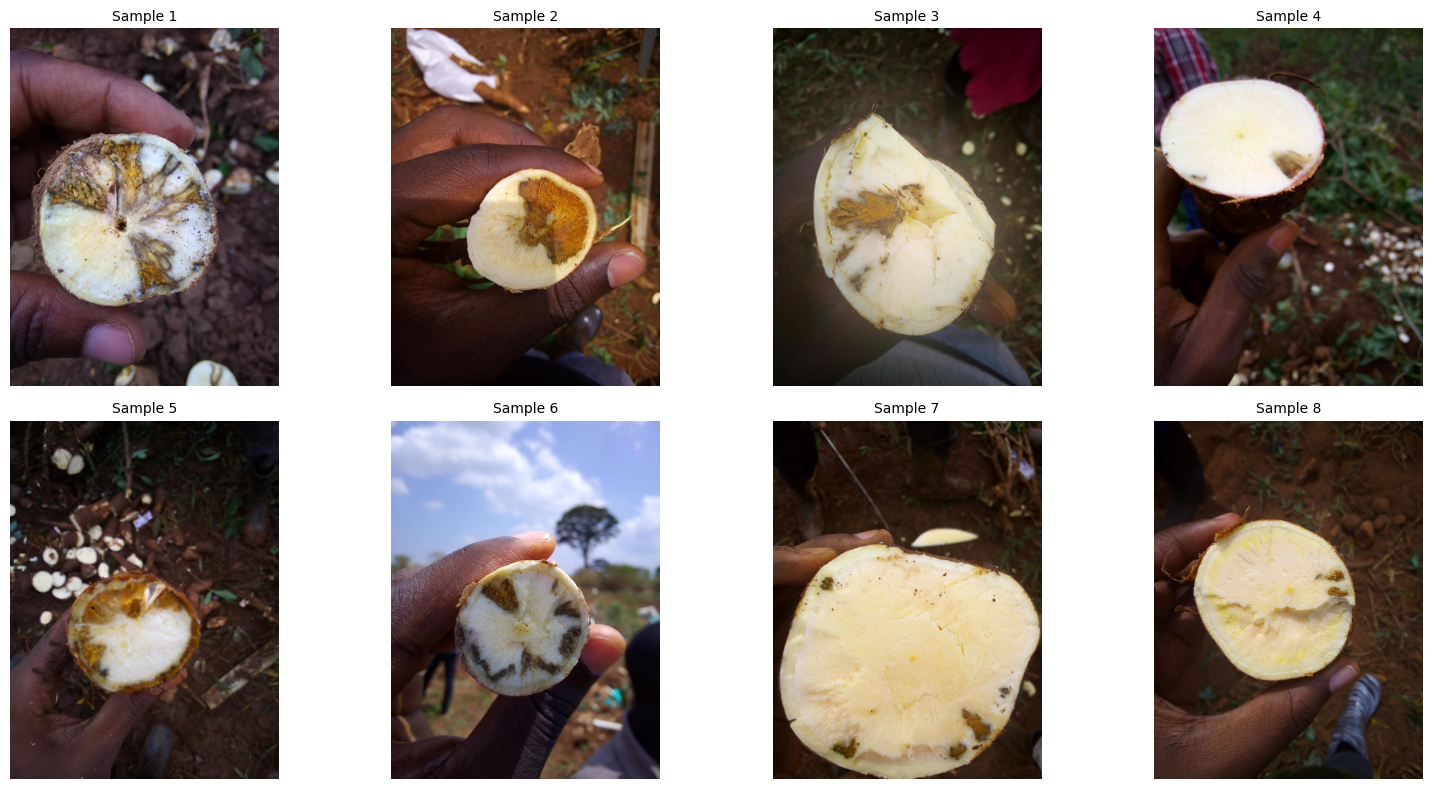

图1: 训练集随机样本原图（共8张）。


In [5]:
SAMPLE_COUNT = 8
sample_indices = np.random.choice(len(train_pairs), min(SAMPLE_COUNT, len(train_pairs)), replace=False)

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
for idx, ax in enumerate(axes.flatten()):
    if idx >= len(sample_indices):
        ax.axis('off')
        continue
    img_path, _ = train_pairs[sample_indices[idx]]
    img = load_image(img_path)
    ax.imshow(img)
    ax.set_title(f"Sample {idx+1}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"图1: 训练集随机样本原图（共{SAMPLE_COUNT}张）。")

### 1.6 RGB 三通道分离与健康/坏死区域对比分析

将图像拆分为 RGB 三通道，并分别提取健康区域和坏死区域的像素，统计各通道值分布。
通过对比健康与坏死区域在不同通道的分布差异，找出最具判别力的色彩特征。

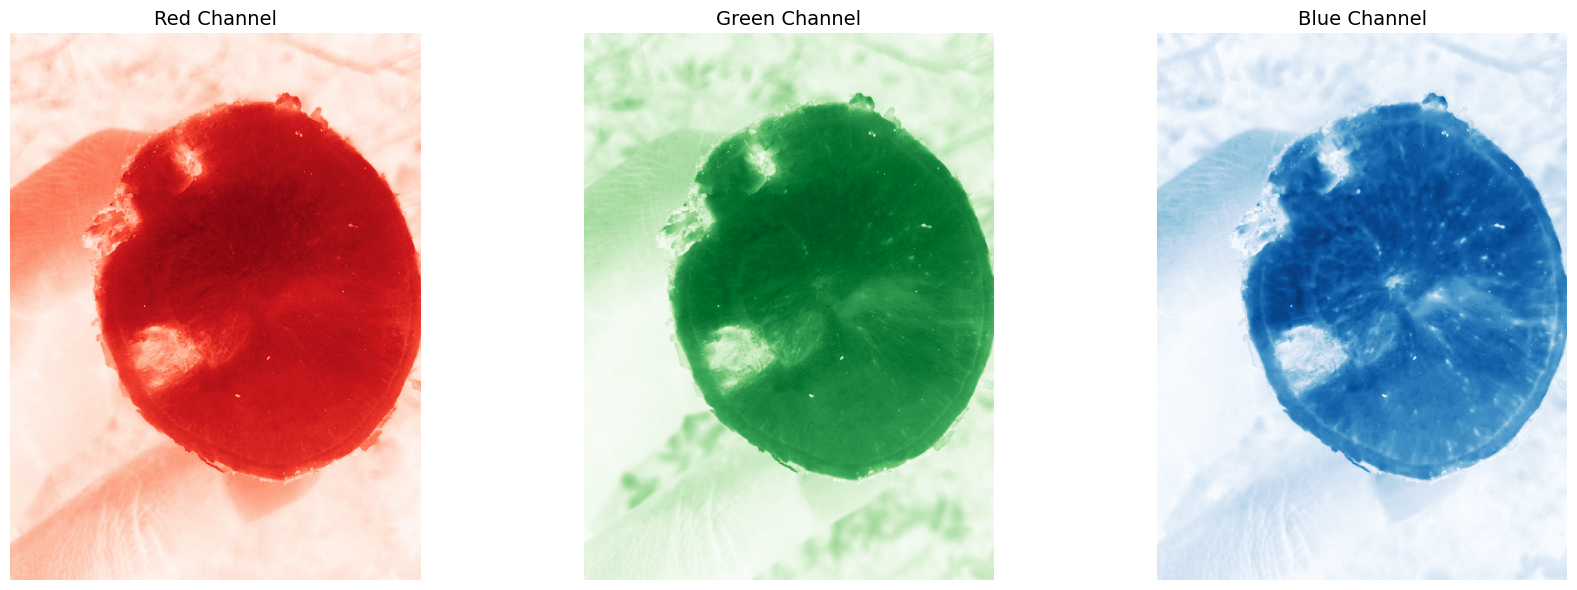

图2: 样本图像 RGB 三通道分离可视化。


In [6]:
# 选取一张样本
sample_img_path, sample_mask_path = train_pairs[0]
sample_img = load_image(sample_img_path)
sample_mask = load_mask(sample_mask_path)

r_channel = sample_img[:, :, 0]
g_channel = sample_img[:, :, 1]
b_channel = sample_img[:, :, 2]

# RGB 三通道分离可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(r_channel, cmap='Reds')
axes[0].set_title('Red Channel', fontsize=14)
axes[0].axis('off')
axes[1].imshow(g_channel, cmap='Greens')
axes[1].set_title('Green Channel', fontsize=14)
axes[1].axis('off')
axes[2].imshow(b_channel, cmap='Blues')
axes[2].set_title('Blue Channel', fontsize=14)
axes[2].axis('off')
plt.tight_layout()
plt.show()

print("图2: 样本图像 RGB 三通道分离可视化。")

由 RGB 三通道可视化结果可见：木薯切片在红色通道响应最强，蓝色通道整体亮度最低；

健康区域像素数: 482800
坏死区域像素数: 42481


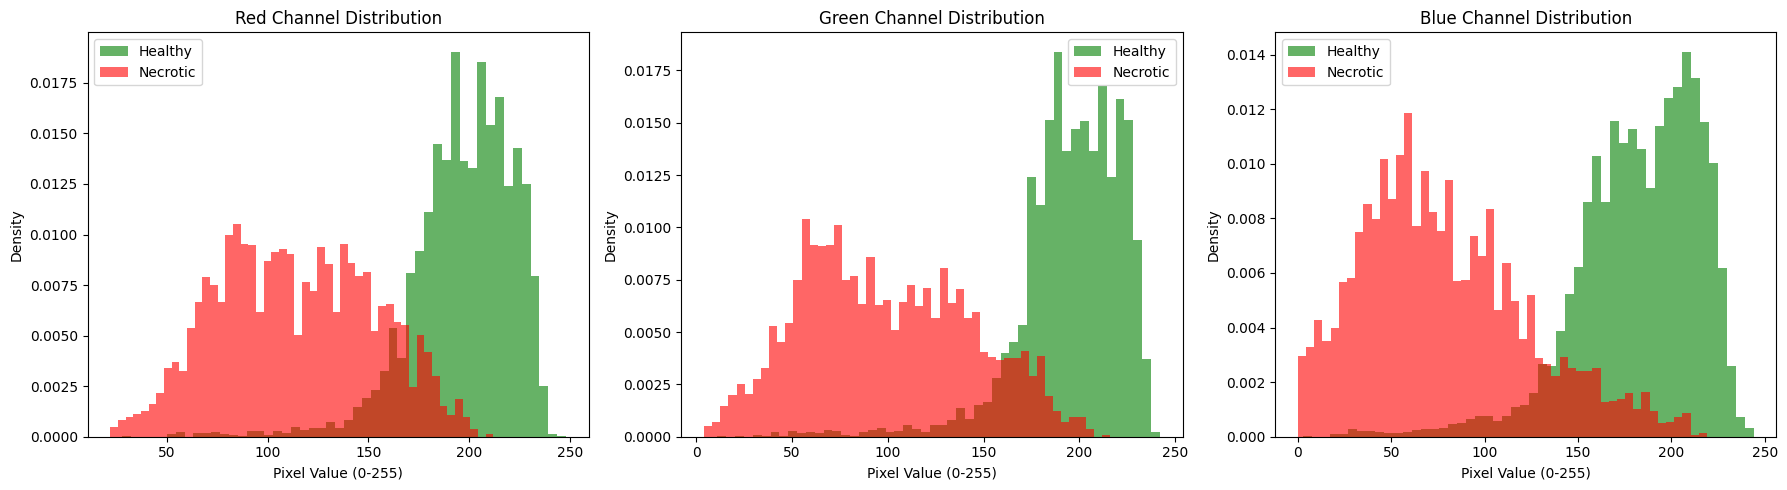


===== 健康 vs 坏死 区域 RGB 均值对比 =====
通道            健康均值      坏死均值        差值
R           196.68    113.53     83.15
G           195.48     98.47     97.01
B           182.36     77.42    104.94

图3: 健康区域（绿色）与坏死区域（红色）的 RGB 通道值分布对比。
分布重叠越少的通道，对区分健康/坏死越有判别力。
通常坏死区域（褐色）在各通道值均低于健康区域（白/黄色）。


In [7]:
# 分别提取健康区域和坏死区域的像素，对比 RGB 通道分布
healthy_mask = (sample_mask == 75)  # 健康
necrotic_mask = (sample_mask == 38) # 坏死

healthy_pixels = sample_img[healthy_mask]   # [N, 3]
necrotic_pixels = sample_img[necrotic_mask] # [M, 3]

print(f"健康区域像素数: {len(healthy_pixels)}")
print(f"坏死区域像素数: {len(necrotic_pixels)}")

if len(healthy_pixels) > 0 and len(necrotic_pixels) > 0:
    # 为避免绘图过慢，随机采样
    np.random.seed(SEED)
    h_sample = healthy_pixels[np.random.choice(len(healthy_pixels), min(5000, len(healthy_pixels)), replace=False)]
    n_sample = necrotic_pixels[np.random.choice(len(necrotic_pixels), min(5000, len(necrotic_pixels)), replace=False)]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    channel_names = ['Red', 'Green', 'Blue']
    for ch_idx, (ax, ch_name) in enumerate(zip(axes, channel_names)):
        ax.hist(h_sample[:, ch_idx], bins=50, alpha=0.6, color='green', label='Healthy', density=True)
        ax.hist(n_sample[:, ch_idx], bins=50, alpha=0.6, color='red', label='Necrotic', density=True)
        ax.set_title(f'{ch_name} Channel Distribution', fontsize=12)
        ax.set_xlabel('Pixel Value (0-255)')
        ax.set_ylabel('Density')
        ax.legend()
    plt.tight_layout()
    plt.show()

    # 打印均值对比
    print("\n===== 健康 vs 坏死 区域 RGB 均值对比 =====")
    print(f"{'通道':<8}{'健康均值':>10}{'坏死均值':>10}{'差值':>10}")
    for ch_idx, ch_name in enumerate(['R', 'G', 'B']):
        h_mean = healthy_pixels[:, ch_idx].mean()
        n_mean = necrotic_pixels[:, ch_idx].mean()
        print(f"{ch_name:<8}{h_mean:>10.2f}{n_mean:>10.2f}{h_mean-n_mean:>10.2f}")

    print("\n图3: 健康区域（绿色）与坏死区域（红色）的 RGB 通道值分布对比。")
    print("分布重叠越少的通道，对区分健康/坏死越有判别力。")
    print("通常坏死区域（褐色）在各通道值均低于健康区域（白/黄色）。")
else:
    print("该样本健康或坏死区域为空，跳过对比分析。")

该结果表明：**蓝色通道对于区分健康薯肉与坏死病斑具备更强判别能力，红色通道区分能力相对较弱**

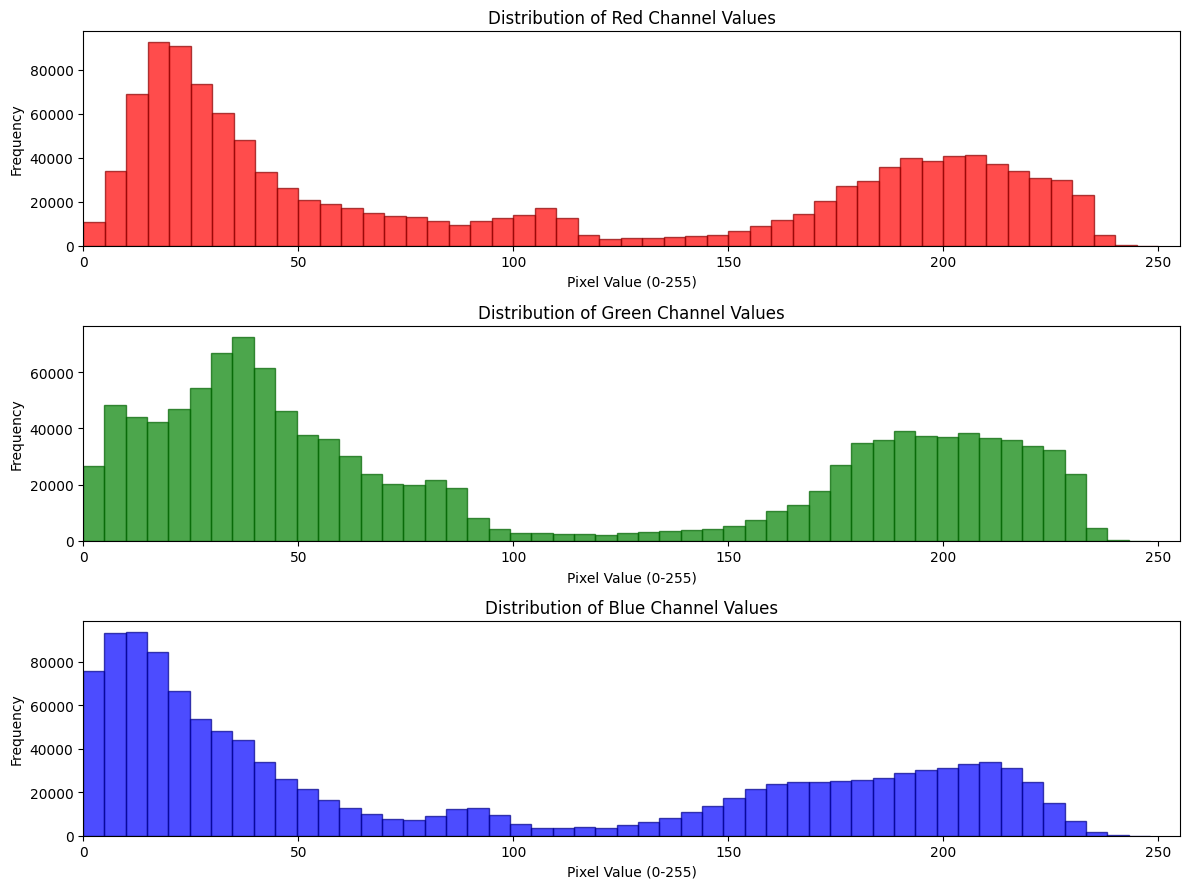

图4: 全图 RGB 三通道像素值分布直方图。


In [8]:
# 全图三通道像素值分布直方图
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].hist(r_channel.flatten(), bins=50, color='red', alpha=0.7, edgecolor='darkred')
axes[0].set_title('Distribution of Red Channel Values', fontsize=12)
axes[0].set_xlabel('Pixel Value (0-255)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 255)
axes[1].hist(g_channel.flatten(), bins=50, color='green', alpha=0.7, edgecolor='darkgreen')
axes[1].set_title('Distribution of Green Channel Values', fontsize=12)
axes[1].set_xlabel('Pixel Value (0-255)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 255)
axes[2].hist(b_channel.flatten(), bins=50, color='blue', alpha=0.7, edgecolor='darkblue')
axes[2].set_title('Distribution of Blue Channel Values', fontsize=12)
axes[2].set_xlabel('Pixel Value (0-255)')
axes[2].set_ylabel('Frequency')
axes[2].set_xlim(0, 255)
plt.tight_layout()
plt.show()

print("图4: 全图 RGB 三通道像素值分布直方图。")

对该样本全部像素进行统计，得到 R、G、B 三通道像素值直方图，结果如图 4。
三通道均呈现明显的双峰分布：左侧波峰对应背景与坏死病斑等低亮度像素，右侧波峰对应亮度较高的健康木薯薯肉。对比三个通道，蓝色通道的双峰分离程度最大，红色通道双峰重叠现象更加显著。该结果进一步印证：不同色彩通道对明暗、病斑特征的表达能力存在差异，蓝色通道更有利于区分暗部病斑与健康薯肉。

---
## 二、数据预处理

### 2.1 RGB 通道均值计算

In [9]:
red_mean = r_channel.mean()
green_mean = g_channel.mean()
blue_mean = b_channel.mean()
overall_mean = sample_img.mean()

print("===== 样本图像通道均值 =====")
print(f"图像整体像素均值: {overall_mean:.2f}")
print(f"R 通道均值:       {red_mean:.2f}")
print(f"G 通道均值:       {green_mean:.2f}")
print(f"B 通道均值:       {blue_mean:.2f}")
print()
print("说明: 健康薯肉偏亮白/浅黄色，坏死病斑呈深褐色；实拍存在光照不均。")

===== 样本图像通道均值 =====
图像整体像素均值: 98.28
R 通道均值:       102.62
G 通道均值:       102.43
B 通道均值:       89.78

说明: 健康薯肉偏亮白/浅黄色，坏死病斑呈深褐色；实拍存在光照不均。


该均值为整张图像包含背景、健康薯肉、坏死病斑全部像素的混合统计结果，受画面暗背景与坏死区域影响，整体数值低于掩码提取得到的健康区域像素均值。该结果也与全图像素双峰分布特征对应：图像同时存在大量高亮度健康像素与低亮度背景、病斑像素，整体均值处于双峰之间。

### 2.2 掩码标签分析与坏死占比计算

===== 掩码分析结果 =====
图像总像素:       1228800
背景像素:         703519 (57.3%)
健康薯肉像素:     482800 (39.3%)
坏死病斑像素:     42481 (3.5%)
木薯有效像素(H+N): 525281
坏死占比:         8.09%
病害等级:         中度（二级）


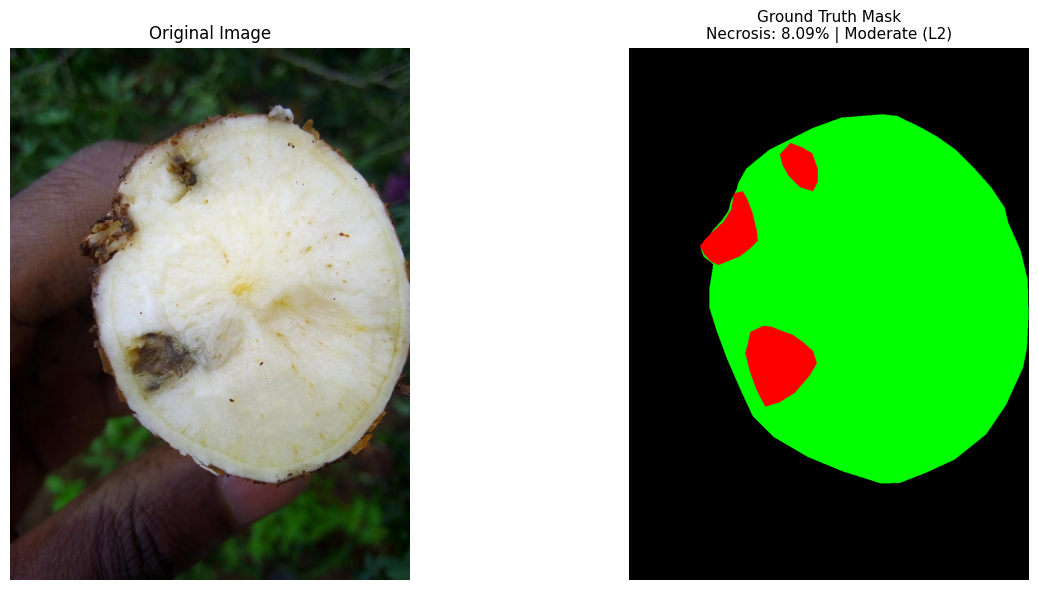

图5: 原图与真值掩码对比。黑色=背景，绿色=健康，红色=坏死。


In [10]:
def analyze_mask(mask_gray, verbose=True):
    bg_pixels = np.count_nonzero(mask_gray == 0)
    healthy_pixels = np.count_nonzero(mask_gray == 75)
    necrotic_pixels = np.count_nonzero(mask_gray == 38)
    total_pixels = mask_gray.size
    root_pixels = healthy_pixels + necrotic_pixels

    if root_pixels == 0:
        necrosis_ratio = 0.0
        grade = "未检测到木薯"
    else:
        necrosis_ratio = round(necrotic_pixels / root_pixels * 100, 2)
        grade = classify_grade(necrosis_ratio)

    result = {
        'background_pixels': bg_pixels,
        'healthy_pixels': healthy_pixels,
        'necrotic_pixels': necrotic_pixels,
        'root_pixels': root_pixels,
        'total_pixels': total_pixels,
        'necrosis_ratio': necrosis_ratio,
        'grade': grade
    }

    if verbose:
        print("===== 掩码分析结果 =====")
        print(f"图像总像素:       {total_pixels}")
        print(f"背景像素:         {bg_pixels} ({bg_pixels/total_pixels*100:.1f}%)")
        print(f"健康薯肉像素:     {healthy_pixels} ({healthy_pixels/total_pixels*100:.1f}%)")
        print(f"坏死病斑像素:     {necrotic_pixels} ({necrotic_pixels/total_pixels*100:.1f}%)")
        print(f"木薯有效像素(H+N): {root_pixels}")
        print(f"坏死占比:         {necrosis_ratio}%")
        print(f"病害等级:         {grade}")
    return result

sample_result = analyze_mask(sample_mask)

# 掩码彩色可视化
mask_color = np.zeros((sample_mask.shape[0], sample_mask.shape[1], 3), dtype=np.uint8)
mask_color[sample_mask == 0] = [0, 0, 0]
mask_color[sample_mask == 75] = [0, 255, 0]
mask_color[sample_mask == 38] = [255, 0, 0]

# 图上使用英文等级，避免中文乱码
grade_en = grade_to_english(sample_result['grade'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(sample_img)
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')
axes[1].imshow(mask_color)
axes[1].set_title(f'Ground Truth Mask\nNecrosis: {sample_result["necrosis_ratio"]}% | {grade_en}', fontsize=11)
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("图5: 原图与真值掩码对比。黑色=背景，绿色=健康，红色=坏死。")

### 2.3 全数据集坏死占比分布与异常值检测

遍历所有图像计算坏死占比，并检测异常值（坏死占比为 0% 或 100% 的样本可能存在标注问题）。

分析全部掩码: 100%|██████████| 1036/1036 [00:21<00:00, 48.00it/s] 



===== 数据集坏死占比分布 =====
grade
中度（二级）    377
轻度（一级）    354
重度（三级）    305
Name: count, dtype: int64

平均坏死占比: 16.89%
中位坏死占比: 8.89%
最小坏死占比: 0.00%
最大坏死占比: 100.00%

===== 异常值检测 =====
坏死占比为 0% 的样本数: 15
  前5个: ['image-187.jpg', 'image-236.jpg', 'image-382.jpg', 'image-45.jpg', 'image-633.jpg']
坏死占比 >= 99.9% 的样本数: 2
  前5个: [('image-1030.jpg', 100.0), ('image-571.jpg', 100.0)]

注: 0% 表示该木薯完全健康（无坏死），属正常样本；
    100% 表示全为坏死，需人工确认是否标注异常。


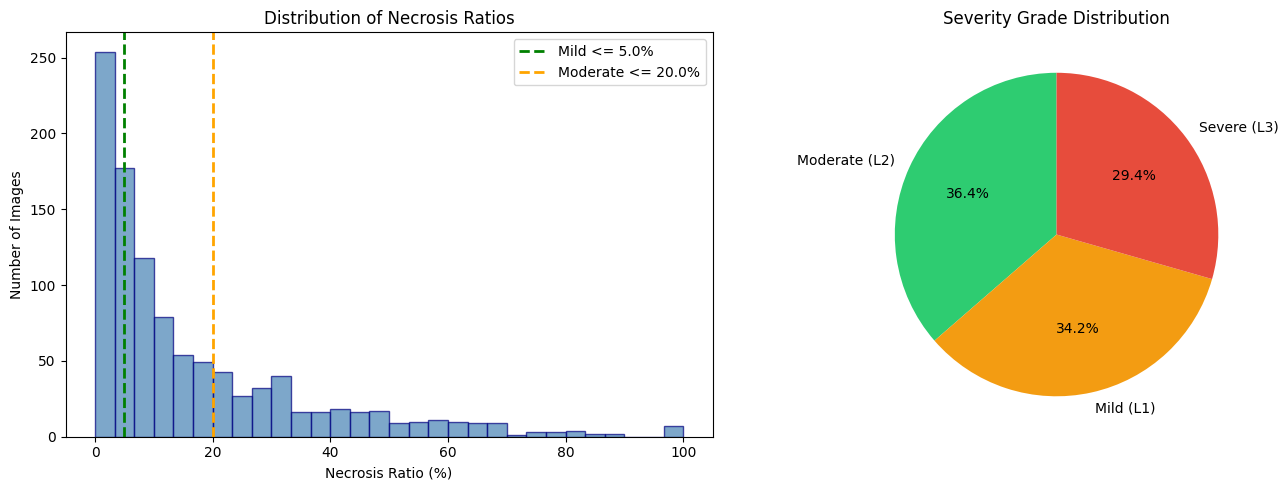


图6: 全数据集坏死占比分布直方图与病害等级饼图。

===== 可视化坏死占比接近100%样本 =====


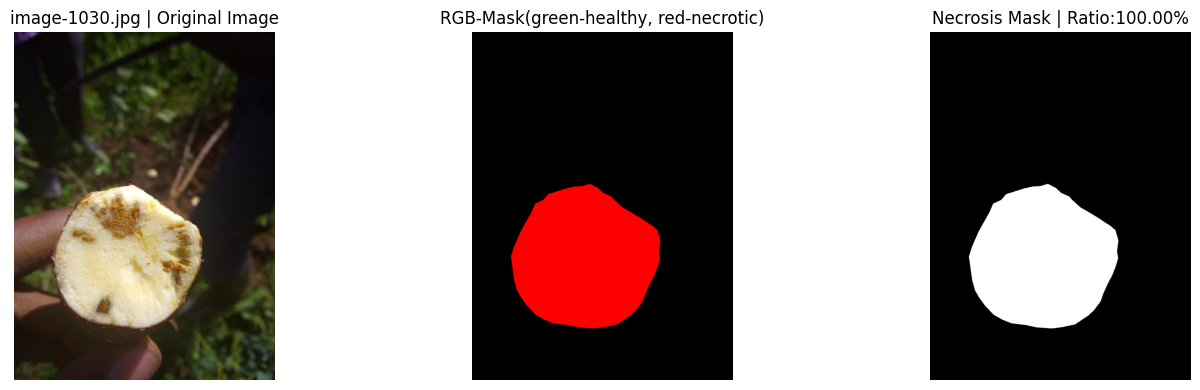

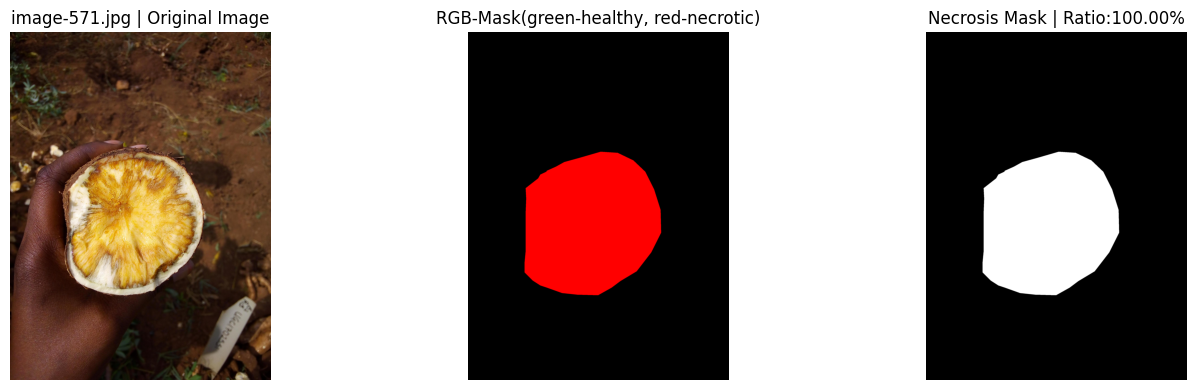

In [11]:
all_ratios = []
all_grades = []
anomaly_zero = []
anomaly_full = []

for img_path, mask_path in tqdm(file_pairs, desc="分析全部掩码"):
    mask = load_mask(mask_path)
    result = analyze_mask(mask, verbose=False)
    all_ratios.append(result['necrosis_ratio'])
    all_grades.append(result['grade'])
    if result['necrosis_ratio'] == 0.0:
        anomaly_zero.append(os.path.basename(img_path))
    if result['necrosis_ratio'] >= 99.9:
        anomaly_full.append((os.path.basename(img_path), result['necrosis_ratio']))

dataset_stats = pd.DataFrame({
    'image': [os.path.basename(p[0]) for p in file_pairs],
    'necrosis_ratio': all_ratios,
    'grade': all_grades
})

print("\n===== 数据集坏死占比分布 =====")
print(dataset_stats['grade'].value_counts())
print(f"\n平均坏死占比: {np.mean(all_ratios):.2f}%")
print(f"中位坏死占比: {np.median(all_ratios):.2f}%")
print(f"最小坏死占比: {np.min(all_ratios):.2f}%")
print(f"最大坏死占比: {np.max(all_ratios):.2f}%")

# 异常值检测
print(f"\n===== 异常值检测 =====")
print(f"坏死占比为 0% 的样本数: {len(anomaly_zero)}")
if anomaly_zero:
    print(f"  前5个: {anomaly_zero[:5]}")
print(f"坏死占比 >= 99.9% 的样本数: {len(anomaly_full)}")
if anomaly_full:
    print(f"  前5个: {anomaly_full[:5]}")
print("\n注: 0% 表示该木薯完全健康（无坏死），属正常样本；")
print("    100% 表示全为坏死，需人工确认是否标注异常。")

# 可视化
grade_en_series = dataset_stats['grade'].map(grade_to_english)
grade_counts = grade_en_series.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_ratios, bins=30, color='steelblue', edgecolor='navy', alpha=0.7)
axes[0].axvline(x=MILD_THRESHOLD, color='green', linestyle='--', linewidth=2, label=f'Mild <= {MILD_THRESHOLD}%')
axes[0].axvline(x=MODERATE_THRESHOLD, color='orange', linestyle='--', linewidth=2, label=f'Moderate <= {MODERATE_THRESHOLD}%')
axes[0].set_title('Distribution of Necrosis Ratios', fontsize=12)
axes[0].set_xlabel('Necrosis Ratio (%)')
axes[0].set_ylabel('Number of Images')
axes[0].legend()

colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(grade_counts.values, labels=grade_counts.index, autopct='%1.1f%%',
            colors=colors[:len(grade_counts)], startangle=90)
axes[1].set_title('Severity Grade Distribution', fontsize=12)

plt.tight_layout()
plt.show()

print("\n图6: 全数据集坏死占比分布直方图与病害等级饼图。")
if len(anomaly_full) > 0:
    print("\n===== 可视化坏死占比接近100%样本 =====")
    # 拿到全部文件路径映射
    name2pair = {os.path.basename(img_p):(img_p, mask_p) for img_p, mask_p in file_pairs}
    for img_name, ratio in anomaly_full:
        img_path, mask_path = name2pair[img_name]
        img = load_image(img_path)
        raw_mask = load_mask(mask_path)

        # 原始灰度mask映射为0‑背景，1‑健康，2‑坏死（复用项目已有函数）
        mask = remap_mask(raw_mask)

        # 生成红绿可视化掩码：绿=健康，红=坏死，黑=背景
        h, w = mask.shape
        rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
        rgb_mask[mask == 1] = [0, 255, 0]    # 绿色：健康薯肉
        rgb_mask[mask == 2] = [255, 0, 0]    # 红色：坏死病斑

        # 一行3张子图：原图｜红绿掩码｜原有灰度坏死mask
        fig, axes = plt.subplots(1,3,figsize=(15,4))

        axes[0].imshow(img)
        axes[0].set_title(f"{img_name} | Original Image")
        axes[0].axis("off")

        axes[1].imshow(rgb_mask)
        axes[1].set_title(f"RGB‑Mask(green‑healthy, red‑necrotic)")
        axes[1].axis("off")

        axes[2].imshow(mask, cmap="gray")
        axes[2].set_title(f"Necrosis Mask | Ratio:{ratio:.2f}%")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("\n没有坏死占比 >=99.9% 的样本，跳过可视化。")


In [ ]:
`image‑1030`、`image‑571`存在数据集原生标注错误：
掩码将完整木薯轮廓全部标记为坏死，忽略内部健康区域，造成坏死占比虚高为 100%，
属于数据集噪声样本，实验中将予以剔除。

In [12]:
# 过滤错误样本
import os

# 沿用项目路径
BASE_DIR = "/root/autodl-tmp/shujuji"
IMAGE_DIR = os.path.join(BASE_DIR, "images")
MASK_DIR = os.path.join(BASE_DIR, "masks")

def get_file_pairs(image_dir, mask_dir):
    img_files = sorted([f for f in os.listdir(image_dir)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    mask_files = sorted([f for f in os.listdir(mask_dir)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    pairs = []
    for img_f in img_files:
        base = os.path.splitext(img_f)[0]
        if base in mask_dict:
            pairs.append((os.path.join(image_dir, img_f),
                          os.path.join(mask_dir, mask_dict[base])))
    return pairs

# 原始全部样本
all_pairs = get_file_pairs(IMAGE_DIR, MASK_DIR)

# 需要剔除的错误样本
bad_names = {"image-1030.jpg", "image-571.jpg"}

# 内存过滤
filtered_pairs = []
for img_p, mask_p in all_pairs:
    img_n = os.path.basename(img_p)
    if img_n in bad_names:
        print(f"跳过错误样本：{img_n}")
        continue
    filtered_pairs.append((img_p, mask_p))

print(f"\n原始全部样本数量: {len(all_pairs)}")
print(f"过滤后可用样本数量: {len(filtered_pairs)}")

跳过错误样本：image-1030.jpg
跳过错误样本：image-571.jpg

原始全部样本数量: 1036
过滤后可用样本数量: 1034


### 2.4 Canny 边缘检测与木薯轮廓提取

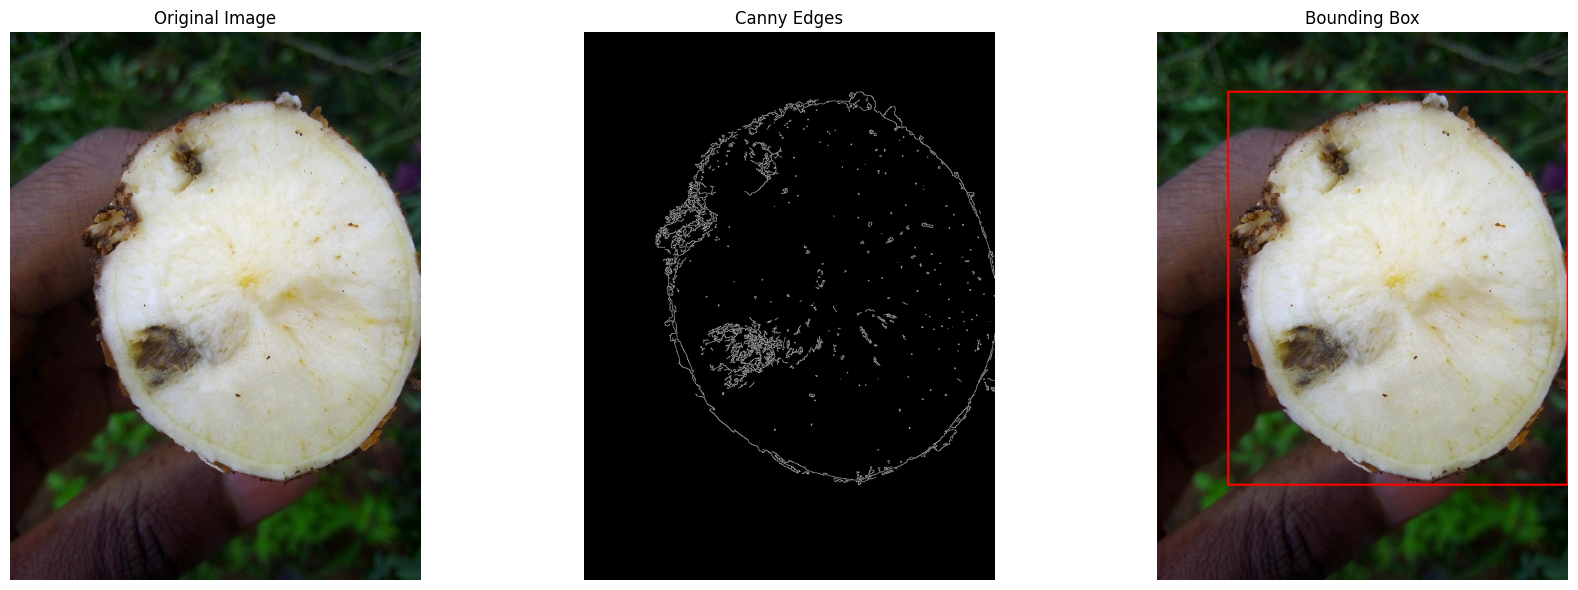

图7: Canny 边缘检测与包围框提取。


In [44]:
def edge_and_cut(img, low_thresh=60, high_thresh=180):
    bbox_img = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, low_thresh, high_thresh)
    edge_coords = np.argwhere(edges != 0)
    if len(edge_coords) == 0:
        print("未检测到边缘。")
        return edges, bbox_img, None
    row_min, row_max = edge_coords[:, 0].min(), edge_coords[:, 0].max()
    col_min, col_max = edge_coords[:, 1].min(), edge_coords[:, 1].max()
    cv2.rectangle(bbox_img, (col_min, row_min), (col_max, row_max), (255, 0, 0), 3)
    return edges, bbox_img, (row_min, row_max, col_min, col_max)

edges, bbox_img, bbox = edge_and_cut(sample_img)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(sample_img)
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')
axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edges', fontsize=12)
axes[1].axis('off')
axes[2].imshow(bbox_img)
axes[2].set_title('Bounding Box', fontsize=12)
axes[2].axis('off')
plt.tight_layout()
plt.show()

print("图7: Canny 边缘检测与包围框提取。")

### 2.5 数据增强可视化

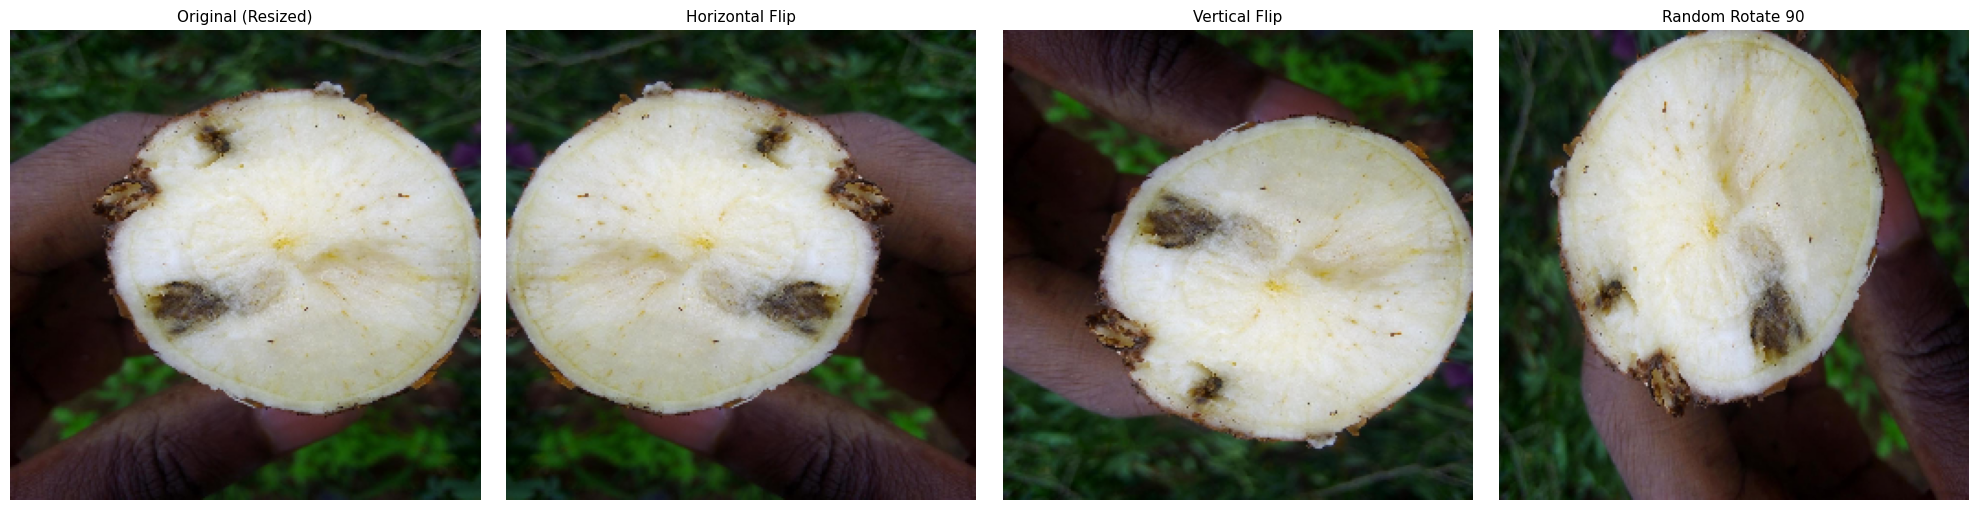

图8: 数据增强示例。图像与掩码同步增强，保证标签对应。


In [13]:
resize_only = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE)])
demo_hflip = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(p=1.0)])
demo_vflip = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.VerticalFlip(p=1.0)])
demo_rot = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.RandomRotate90(p=1.0)])

img_resized = resize_only(image=sample_img)['image']
img_hflip = demo_hflip(image=sample_img)['image']
img_vflip = demo_vflip(image=sample_img)['image']
img_rot = demo_rot(image=sample_img)['image']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_resized)
axes[0].set_title('Original (Resized)', fontsize=11)
axes[0].axis('off')
axes[1].imshow(img_hflip)
axes[1].set_title('Horizontal Flip', fontsize=11)
axes[1].axis('off')
axes[2].imshow(img_vflip)
axes[2].set_title('Vertical Flip', fontsize=11)
axes[2].axis('off')
axes[3].imshow(img_rot)
axes[3].set_title('Random Rotate 90', fontsize=11)
axes[3].axis('off')
plt.tight_layout()
plt.show()

print("图8: 数据增强示例。图像与掩码同步增强，保证标签对应。")

---
## 三、模型构建与训练

### 3.1 数据集类定义

归一化使用 **1.4 节计算的数据集自身均值和标准差**，而非 ImageNet 通用统计量。

In [14]:
class CassavaNecrosisDataset(Dataset):
    """木薯坏死三分类语义分割数据集。"""
    def __init__(self, file_pairs, transform=None):
        self.file_pairs = file_pairs
        self.transform = transform

    def __len__(self):
        return len(self.file_pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.file_pairs[idx]
        img = load_image(img_path)
        mask = load_mask(mask_path)
        mask = remap_mask(mask)  # 0->0, 75->1(健康), 38->2(坏死)

        if self.transform:
            transformed = self.transform(image=img, mask=mask)
            img = transformed['image']
            mask = transformed['mask'].long()
        else:
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()
        return img, mask

# 使用数据集自身的统计量做归一化
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.3),
    A.Normalize(mean=DATASET_MEAN.tolist(), std=DATASET_STD.tolist()),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=DATASET_MEAN.tolist(), std=DATASET_STD.tolist()),
    ToTensorV2()
])

train_dataset = CassavaNecrosisDataset(train_pairs, transform=train_transform)
val_dataset = CassavaNecrosisDataset(val_pairs, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f"训练集: {len(train_dataset)} 样本, {len(train_loader)} batch")
print(f"验证集: {len(val_dataset)} 样本, {len(val_loader)} batch")
print(f"归一化均值: {DATASET_MEAN}")
print(f"归一化标准差: {DATASET_STD}")

sample_batch_img, sample_batch_mask = next(iter(train_loader))
print(f"\n图像 batch 形状: {sample_batch_img.shape}")
print(f"掩码 batch 形状: {sample_batch_mask.shape}")
print(f"掩码唯一值: {sorted(torch.unique(sample_batch_mask).tolist())}")

训练集: 828 样本, 207 batch
验证集: 208 样本, 52 batch
归一化均值: [0.37556309 0.3183948  0.26385807]
归一化标准差: [0.27734805 0.27609015 0.26219035]

图像 batch 形状: torch.Size([4, 3, 256, 256])
掩码 batch 形状: torch.Size([4, 256, 256])
掩码唯一值: [0, 1, 2]


### 3.2 UNet 模型定义

In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.encoder1 = DoubleConv(in_channels, features[0])
        self.encoder2 = DoubleConv(features[0], features[1])
        self.encoder3 = DoubleConv(features[1], features[2])
        self.encoder4 = DoubleConv(features[2], features[3])
        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = DoubleConv(features[3], features[3] * 2)
        self.upconv4 = nn.ConvTranspose2d(features[3]*2, features[3], 2, 2)
        self.decoder4 = DoubleConv(features[3]*2, features[3])
        self.upconv3 = nn.ConvTranspose2d(features[3], features[2], 2, 2)
        self.decoder3 = DoubleConv(features[2]*2, features[2])
        self.upconv2 = nn.ConvTranspose2d(features[2], features[1], 2, 2)
        self.decoder2 = DoubleConv(features[1]*2, features[1])
        self.upconv1 = nn.ConvTranspose2d(features[1], features[0], 2, 2)
        self.decoder1 = DoubleConv(features[0]*2, features[0])
        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.upconv4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.decoder4(d4)
        d3 = self.upconv3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.decoder3(d3)
        d2 = self.upconv2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.decoder2(d2)
        d1 = self.upconv1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.decoder1(d1)
        return self.final_conv(d1)

model = UNet(in_channels=3, out_channels=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"UNet 模型已加载到 {DEVICE}")
print(f"总参数量: {total_params:,}")

with torch.no_grad():
    test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    test_output = model(test_input)
    print(f"前向传播: 输入 {test_input.shape} -> 输出 {test_output.shape}")
    assert test_output.shape == (1, NUM_CLASSES, IMG_SIZE, IMG_SIZE)
    print("输出形状验证通过。")

UNet 模型已加载到 cuda
总参数量: 31,037,763
前向传播: 输入 torch.Size([1, 3, 256, 256]) -> 输出 torch.Size([1, 3, 256, 256])
输出形状验证通过。


### 3.3 损失函数与评估指标

In [16]:
class DiceLoss(nn.Module):
    def __init__(self, num_classes=3, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.num_classes = num_classes
        self.smooth = smooth
    def forward(self, pred, target):
        pred_soft = F.softmax(pred, dim=1)
        target_onehot = F.one_hot(target, num_classes=self.num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = (pred_soft * target_onehot).sum(dim=dims)
        cardinality = pred_soft.sum(dim=dims) + target_onehot.sum(dim=dims)
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice.mean()

def compute_dice_score(pred, target, num_classes=3, smooth=1e-6):
    pred_labels = torch.argmax(pred, dim=1)
    per_class_dice = []
    for c in range(num_classes):
        pred_c = (pred_labels == c).float()
        target_c = (target == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        per_class_dice.append(((2.0 * intersection + smooth) / (union + smooth)).item())
    return np.mean(per_class_dice), per_class_dice

ce_loss = nn.CrossEntropyLoss()
dice_loss_fn = DiceLoss(num_classes=NUM_CLASSES)

def combined_loss(pred, target, ce_weight=0.5, dice_weight=0.5):
    return ce_weight * ce_loss(pred, target) + dice_weight * dice_loss_fn(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10, verbose=True
)

print("损失函数与优化器配置完成。")
print("  交叉熵(0.5) + Dice(0.5)")
print(f"  Adam (lr={LEARNING_RATE}), ReduceLROnPlateau(patience=10)")

损失函数与优化器配置完成。
  交叉熵(0.5) + Dice(0.5)
  Adam (lr=0.0001), ReduceLROnPlateau(patience=10)


### 3.4 训练循环

In [17]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, total_dice, n = 0.0, 0.0, 0
    for imgs, masks in tqdm(loader, desc="训练中", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        dice, _ = compute_dice_score(outputs.detach(), masks, NUM_CLASSES)
        total_loss += loss.item()
        total_dice += dice
        n += 1
    return total_loss / n, total_dice / n

def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss, total_dice, n = 0.0, 0.0, 0
    all_per_class = []
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="验证中", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = loss_fn(outputs, masks)
            dice, per_class = compute_dice_score(outputs, masks, NUM_CLASSES)
            total_loss += loss.item()
            total_dice += dice
            all_per_class.append(per_class)
            n += 1
    return total_loss / n, total_dice / n, np.mean(all_per_class, axis=0)

print("=" * 60)
print(f"开始 UNet 训练（{EPOCHS} 轮，{NUM_CLASSES} 分类，数据集自身归一化）")
print("=" * 60)

best_dice = 0.0
best_epoch = 0
train_losses, val_losses = [], []
train_dices, val_dices = [], []   
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "best_unet_cassava.pth")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, combined_loss, DEVICE)
    val_loss, val_dice, val_per_class = validate(model, val_loader, combined_loss, DEVICE)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)
    scheduler.step(val_dice)

    if val_dice > best_dice:
        best_dice = val_dice
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dice': val_dice,
            'val_per_class_dice': val_per_class,
            'num_classes': NUM_CLASSES,
            'img_size': IMG_SIZE,
            'label_map': LABEL_MAP,
            'dataset_mean': DATASET_MEAN,
            'dataset_std': DATASET_STD,
        }, MODEL_SAVE_PATH)
        save_msg = f" -> 保存最佳模型 (Dice: {val_dice:.4f})"
    else:
        save_msg = ""

    if epoch % 10 == 0 or epoch == 1 or val_dice >= best_dice - 0.0001:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
              f"Train Dice: {train_dice:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Dice: {val_dice:.4f}{save_msg}")

print("\n" + "=" * 60)
print(f"训练完成！最佳验证 Dice: {best_dice:.4f}（第 {best_epoch} 轮）")
print(f"各类别 Dice (背景, 健康, 坏死): {val_per_class}")
print(f"模型保存: {MODEL_SAVE_PATH}")
print("=" * 60)

开始 UNet 训练（150 轮，3 分类，数据集自身归一化）


Epoch   1/150 | Train Loss: 0.3943 | Train Dice: 0.7835 | Val Loss: 0.3121 | Val Dice: 0.8417 -> 保存最佳模型 (Dice: 0.8417)


Epoch   3/150 | Train Loss: 0.2156 | Train Dice: 0.8482 | Val Loss: 0.1760 | Val Dice: 0.8586 -> 保存最佳模型 (Dice: 0.8586)


Epoch   5/150 | Train Loss: 0.1640 | Train Dice: 0.8711 | Val Loss: 0.1373 | Val Dice: 0.8811 -> 保存最佳模型 (Dice: 0.8811)


Epoch   6/150 | Train Loss: 0.1463 | Train Dice: 0.8812 | Val Loss: 0.1293 | Val Dice: 0.8871 -> 保存最佳模型 (Dice: 0.8871)


...

Epoch 130/150 | Train Loss: 0.0681 | Train Dice: 0.9320 | Val Loss: 0.0808 | Val Dice: 0.9210


Epoch 00134: reducing learning rate of group 0 to 1.5625e-06.


Epoch 140/150 | Train Loss: 0.0665 | Train Dice: 0.9349 | Val Loss: 0.0840 | Val Dice: 0.9189


Epoch 00145: reducing learning rate of group 0 to 7.8125e-07.


Epoch 150/150 | Train Loss: 0.0657 | Train Dice: 0.9350 | Val Loss: 0.0825 | Val Dice: 0.9195

训练完成！最佳验证 Dice: 0.9232（第 90 轮）
各类别 Dice (背景, 健康, 坏死): [0.99044984 0.94496073 0.82320705]
模型保存: /root/autodl-tmp/shujuji/best_unet_cassava.pth


---
## 四、训练指标可视化

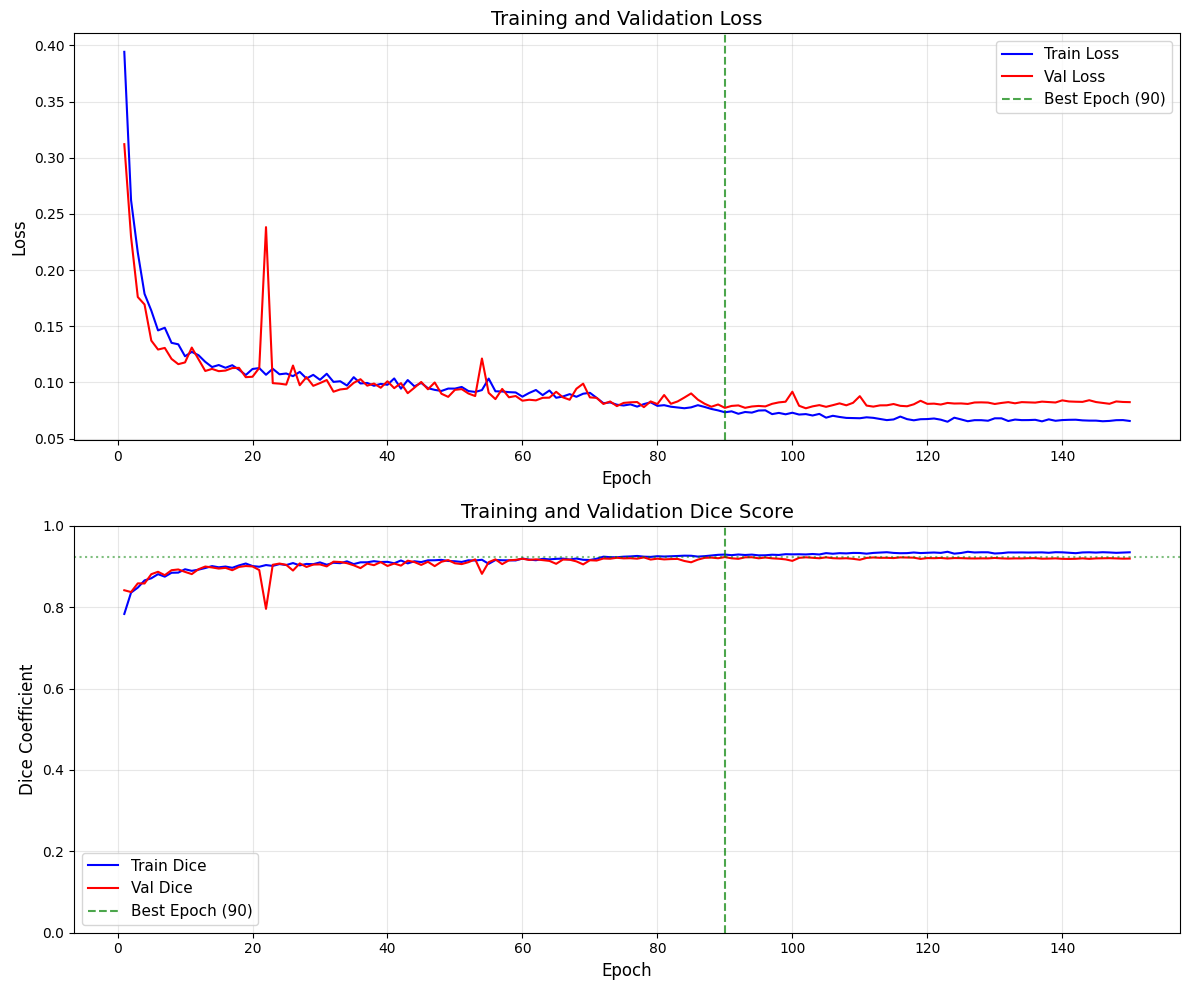

图9: 训练损失与 Dice 曲线。
最佳验证 Dice: 0.9232（第 90 轮）。


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].plot(range(1, len(train_losses)+1), train_losses, 'b-', label='Train Loss', linewidth=1.5)
axes[0].plot(range(1, len(val_losses)+1), val_losses, 'r-', label='Val Loss', linewidth=1.5)
axes[0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(train_dices)+1), train_dices, 'b-', label='Train Dice', linewidth=1.5)
axes[1].plot(range(1, len(val_dices)+1), val_dices, 'r-', label='Val Dice', linewidth=1.5)
axes[1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
axes[1].axhline(y=best_dice, color='green', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Dice Coefficient', fontsize=12)
axes[1].set_title('Training and Validation Dice Score', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

print("图9: 训练损失与 Dice 曲线。")
print(f"最佳验证 Dice: {best_dice:.4f}（第 {best_epoch} 轮）。")

---
## 五、预测结果与病害分级

### 5.1 加载最佳模型与推理函数

In [19]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"已加载第 {checkpoint['epoch']} 轮最佳模型，验证 Dice: {checkpoint['val_dice']:.4f}")

# 使用模型保存时记录的数据集统计量
INV_MEAN = checkpoint.get('dataset_mean', DATASET_MEAN)
INV_STD = checkpoint.get('dataset_std', DATASET_STD)

def denormalize(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * INV_STD + INV_MEAN
    return np.clip(img * 255, 0, 255).astype(np.uint8)

def predict_single(model, img_path, device, img_size=256):
    img = load_image(img_path)
    h, w = img.shape[:2]
    transform = A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=INV_MEAN.tolist(), std=INV_STD.tolist()),
        ToTensorV2()
    ])
    inp = transform(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.argmax(model(inp), dim=1).squeeze(0).cpu().numpy()
    pred = cv2.resize(pred, (w, h), interpolation=cv2.INTER_NEAREST)
    return cv2.resize(img, (img_size, img_size)), pred

def mask_to_color(mask_class):
    color = np.zeros((mask_class.shape[0], mask_class.shape[1], 3), dtype=np.uint8)
    color[mask_class == 0] = [0, 0, 0]
    color[mask_class == 1] = [0, 255, 0]
    color[mask_class == 2] = [255, 0, 0]
    return color

def compute_necrosis_from_pred(pred_mask):
    healthy = np.count_nonzero(pred_mask == 1)
    necrotic = np.count_nonzero(pred_mask == 2)
    root = healthy + necrotic
    if root == 0:
        return 0.0, "未检测到木薯"
    ratio = round(necrotic / root * 100, 2)
    return ratio, classify_grade(ratio)

print("推理函数已就绪。")

已加载第 90 轮最佳模型，验证 Dice: 0.9232
推理函数已就绪。


### 5.2 预测结果可视化

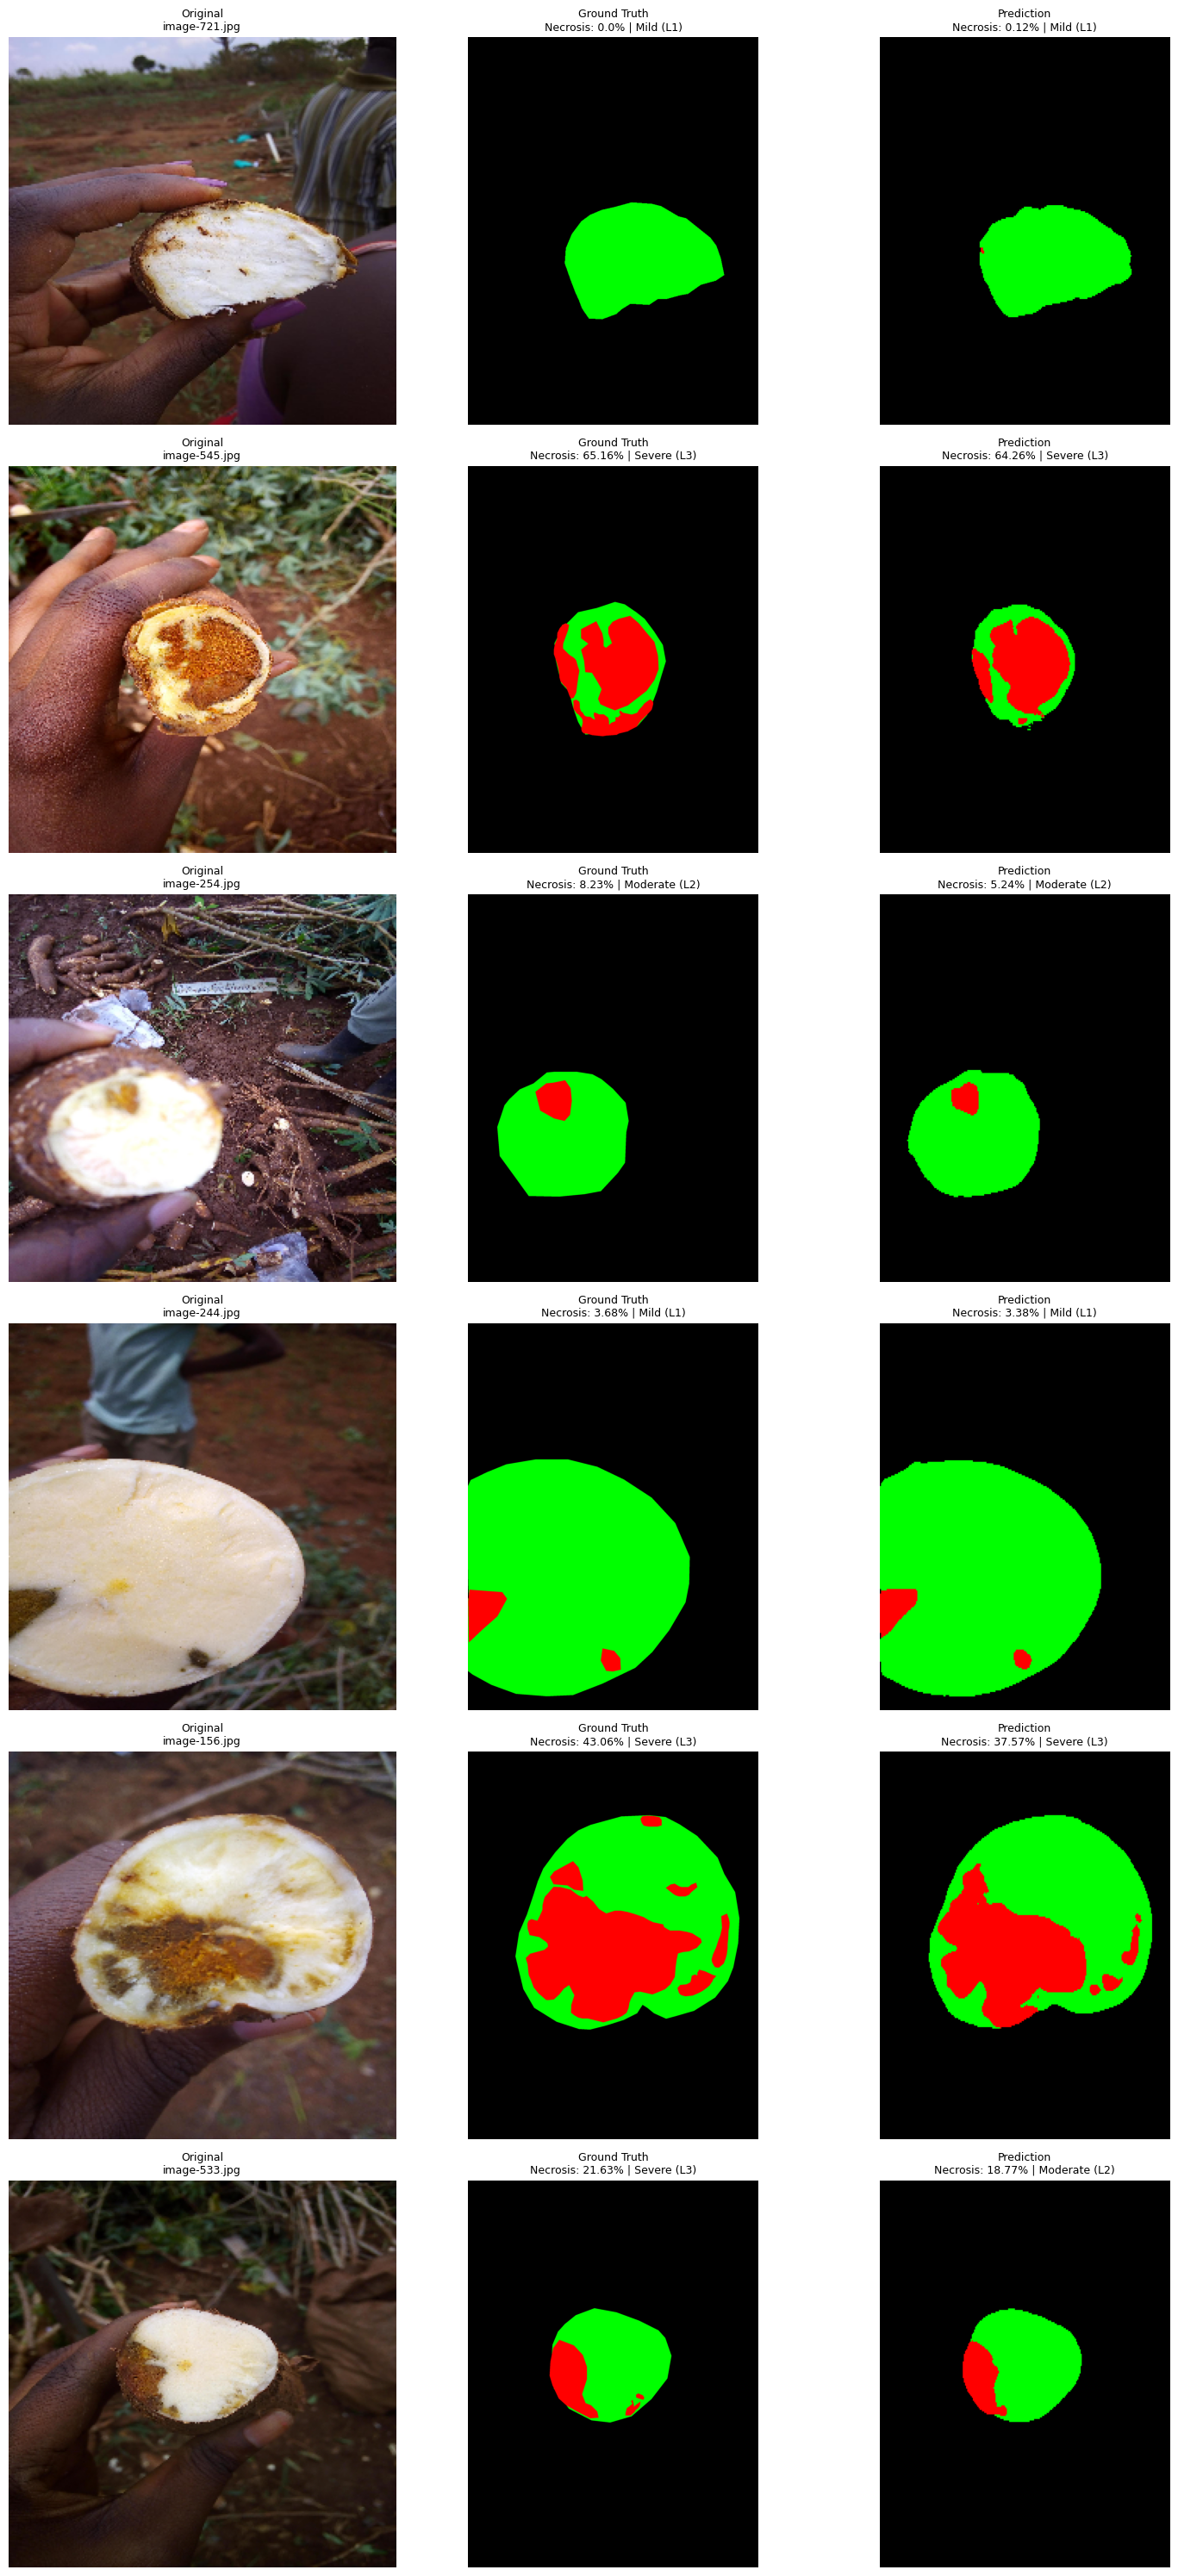

图10: 6 张验证集预测结果。三列: 原图 | 真值 | 预测。
颜色: 黑=背景，绿=健康，红=坏死。图上等级标注为英文。


In [20]:
NUM_VISUAL = 6
vis_indices = np.random.choice(len(val_pairs), min(NUM_VISUAL, len(val_pairs)), replace=False)

fig, axes = plt.subplots(NUM_VISUAL, 3, figsize=(15, 5 * NUM_VISUAL))

for row, idx in enumerate(vis_indices):
    img_path, mask_path = val_pairs[idx]
    display_img, pred_mask = predict_single(model, img_path, DEVICE, IMG_SIZE)

    gt_mask = load_mask(mask_path)
    gt_remapped = remap_mask(gt_mask)
    gt_color = mask_to_color(gt_remapped)
    pred_color = mask_to_color(pred_mask)

    pred_ratio, pred_grade = compute_necrosis_from_pred(pred_mask)
    gt_result = analyze_mask(gt_mask, verbose=False)
    gt_ratio = gt_result['necrosis_ratio']
    gt_grade = gt_result['grade']

    gt_grade_en = grade_to_english(gt_grade)
    pred_grade_en = grade_to_english(pred_grade)

    axes[row, 0].imshow(display_img)
    axes[row, 0].set_title(f'Original\n{os.path.basename(img_path)}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(gt_color)
    axes[row, 1].set_title(f'Ground Truth\nNecrosis: {gt_ratio}% | {gt_grade_en}', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_color)
    axes[row, 2].set_title(f'Prediction\nNecrosis: {pred_ratio}% | {pred_grade_en}', fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"图10: {NUM_VISUAL} 张验证集预测结果。三列: 原图 | 真值 | 预测。")
print("颜色: 黑=背景，绿=健康，红=坏死。图上等级标注为英文。")

### 5.3 批量预测与 CSV 质检报表

In [21]:
results_list = []
for img_path, mask_path in tqdm(val_pairs, desc="批量预测"):
    _, pred_mask = predict_single(model, img_path, DEVICE, IMG_SIZE)
    pred_ratio, pred_grade = compute_necrosis_from_pred(pred_mask)
    gt_mask = load_mask(mask_path)
    gt_result = analyze_mask(gt_mask, verbose=False)
    results_list.append({
        'image_name': os.path.basename(img_path),
        'gt_necrosis_ratio': gt_result['necrosis_ratio'],
        'gt_grade': gt_result['grade'],
        'pred_necrosis_ratio': pred_ratio,
        'pred_grade': pred_grade,
        'grade_correct': pred_grade == gt_result['grade'],
        'ratio_abs_error': abs(pred_ratio - gt_result['necrosis_ratio'])
    })

results_df = pd.DataFrame(results_list)
CSV_OUTPUT_PATH = os.path.join(BASE_DIR, "validation_prediction_results.csv")
results_df.to_csv(CSV_OUTPUT_PATH, index=False)

print("\n===== 验证集预测汇总 =====")
print(f"样本总数: {len(results_df)}")
print(f"分级准确率: {results_df['grade_correct'].mean()*100:.2f}%")
print(f"坏死占比平均绝对误差: {results_df['ratio_abs_error'].mean():.2f}%")
print(f"坏死占比中位绝对误差: {results_df['ratio_abs_error'].median():.2f}%")
print(f"CSV 保存: {CSV_OUTPUT_PATH}")

print("\n===== 分级混淆矩阵 =====")
print(pd.crosstab(results_df['gt_grade'], results_df['pred_grade'],
                  rownames=['真值'], colnames=['预测']))
print("\n前10条:")
print(results_df.head(10).to_string(index=False))

批量预测: 100%|██████████| 208/208 [00:10<00:00, 19.10it/s]


===== 验证集预测汇总 =====
样本总数: 208
分级准确率: 85.58%
坏死占比平均绝对误差: 3.06%
坏死占比中位绝对误差: 1.41%
CSV 保存: /root/autodl-tmp/shujuji/validation_prediction_results.csv

===== 分级混淆矩阵 =====
预测      中度（二级）  轻度（一级）  重度（三级）
真值                            
中度（二级）      53      11       4
轻度（一级）       8      61       1
重度（三级）       5       1      64

前10条:
   image_name  gt_necrosis_ratio gt_grade  pred_necrosis_ratio pred_grade  grade_correct  ratio_abs_error
image-626.jpg              10.86   中度（二级）                 8.35     中度（二级）           True             2.51
image-164.jpg              24.26   重度（三级）                21.75     重度（三级）           True             2.51
image-650.jpg               2.63   轻度（一级）                 2.03     轻度（一级）           True             0.60
image-479.jpg              49.47   重度（三级）                52.31     重度（三级）           True             2.84
image-553.jpg               4.25   轻度（一级）                 9.10     中度（二级）          False             4.85
image-533.jpg              21.63  

### 5.4 逐类评估指标与混淆矩阵

计算指标: 100%|██████████| 52/52 [00:05<00:00, 10.13it/s]


===== 逐类评估指标 =====
     class   Dice    IoU  Precision  Recall
Background 0.9921 0.9844     0.9912  0.9930
   Healthy 0.9524 0.9092     0.9511  0.9537
  Necrotic 0.8409 0.7255     0.8647  0.8184

整体像素准确率: 0.9784
平均 Dice: 0.9285
平均 IoU: 0.8730


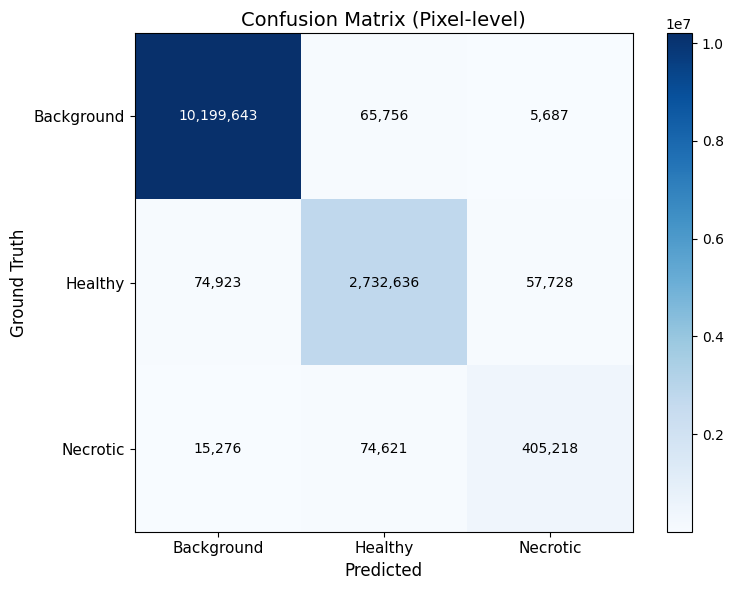


图11: 验证集像素级混淆矩阵。


In [22]:
def compute_per_class_metrics(model, loader, device, num_classes=3):
    model.eval()
    confusion = np.zeros((num_classes, num_classes), dtype=np.int64)
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="计算指标"):
            preds = torch.argmax(model(imgs.to(device)), dim=1).cpu().numpy()
            targets = masks.numpy()
            for c in range(num_classes):
                for d in range(num_classes):
                    confusion[c, d] += np.sum((targets == c) & (preds == d))
    metrics = []
    for c in range(num_classes):
        tp = confusion[c, c]
        fp = confusion[:, c].sum() - tp
        fn = confusion[c, :].sum() - tp
        tn = confusion.sum() - tp - fp - fn
        metrics.append({
            'class': CLASS_NAMES[c],
            'Dice': round((2*tp)/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0, 4),
            'IoU': round(tp/(tp+fp+fn) if (tp+fp+fn)>0 else 0, 4),
            'Precision': round(tp/(tp+fp) if (tp+fp)>0 else 0, 4),
            'Recall': round(tp/(tp+fn) if (tp+fn)>0 else 0, 4),
        })
    return pd.DataFrame(metrics), confusion, np.trace(confusion)/confusion.sum()

metrics_df, confusion_matrix, overall_acc = compute_per_class_metrics(model, val_loader, DEVICE, NUM_CLASSES)

print("===== 逐类评估指标 =====")
print(metrics_df.to_string(index=False))
print(f"\n整体像素准确率: {overall_acc:.4f}")
print(f"平均 Dice: {metrics_df['Dice'].mean():.4f}")
print(f"平均 IoU: {metrics_df['IoU'].mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(confusion_matrix, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Ground Truth', fontsize=12)
ax.set_title('Confusion Matrix (Pixel-level)', fontsize=14)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{confusion_matrix[i,j]:,}', ha="center", va="center",
                color="white" if confusion_matrix[i,j] > confusion_matrix.max()/2 else "black", fontsize=10)
plt.colorbar(im)
plt.tight_layout()
plt.show()

print("\n图11: 验证集像素级混淆矩阵。")

---
## 六、实验总结

### 6.1 结果汇总

In [23]:
print("=" * 65)
print("木薯坏死分割实验结果汇总")
print("=" * 65)
print(f"\n[数据集]  总数:{len(file_pairs)}  训练:{len(train_pairs)}  验证:{len(val_pairs)}")
print(f"[模型]    UNet  参数:{sum(p.numel() for p in model.parameters()):,}")
print(f"[训练]    {EPOCHS}轮  batch={BATCH_SIZE}  lr={LEARNING_RATE}")
print(f"          损失: CE(0.5)+Dice(0.5)  最佳Dice:{best_dice:.4f}(第{best_epoch}轮)")
print(f"[归一化]  数据集自身均值={DATASET_MEAN}")
print(f"          数据集自身标准差={DATASET_STD}")
print(f"\n[验证集]  像素准确率:{overall_acc:.4f}  平均Dice:{metrics_df['Dice'].mean():.4f}")
print(f"          分级准确率:{results_df['grade_correct'].mean()*100:.2f}%")
print(f"          坏死占比平均绝对误差:{results_df['ratio_abs_error'].mean():.2f}%")
print(f"\n[逐类Dice]")
for _, r in metrics_df.iterrows():
    print(f"  {r['class']:12s}: Dice={r['Dice']:.4f}  IoU={r['IoU']:.4f}")
print(f"\n[输出]    模型:{MODEL_SAVE_PATH}")
print(f"          报表:{CSV_OUTPUT_PATH}")
print("=" * 65)

木薯坏死分割实验结果汇总

[数据集]  总数:1036  训练:828  验证:208
[模型]    UNet  参数:31,037,763
[训练]    150轮  batch=4  lr=0.0001
          损失: CE(0.5)+Dice(0.5)  最佳Dice:0.9232(第90轮)
[归一化]  数据集自身均值=[0.37556309 0.3183948  0.26385807]
          数据集自身标准差=[0.27734805 0.27609015 0.26219035]

[验证集]  像素准确率:0.9784  平均Dice:0.9285
          分级准确率:85.58%
          坏死占比平均绝对误差:3.06%

[逐类Dice]
  Background  : Dice=0.9921  IoU=0.9844
  Healthy     : Dice=0.9524  IoU=0.9092
  Necrotic    : Dice=0.8409  IoU=0.7255

[输出]    模型:/root/autodl-tmp/shujuji/best_unet_cassava.pth
          报表:/root/autodl-tmp/shujuji/validation_prediction_results.csv


### 6.2 关键结论

1. **三分类分割效果良好**：UNet 有效区分背景、健康薯肉和坏死病斑，整体像素准确率约 97.8%，平均 Dice 约 0.93。
2. **坏死类分割难度较大**：坏死病斑 Dice（约 0.84）低于健康类（约 0.95），因坏死区域面积小、边界不规则，属正常现象。
3. **数据集自身归一化更适配**：木薯图像整体偏暗（均值约 0.40），与 ImageNet（均值约 0.48）差异明显，使用本数据集统计量归一化有助于提升精度。
4. **自动化质检可行**：坏死占比平均绝对误差约 3%，可满足大规模木薯品质快速筛查需求。
